# KNN classifier
> drug_class.csv

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier

In [2]:
df = pd.read_csv('drug_class.csv')
df.head()

,Age,Gender,BloodPressure,Cholestrol,Na_to_K,Class
0,23,M,LOW,HIGH,7.301033,drugC
1,69,M,LOW,HIGH,15.478000,drugY
2,74,M,HIGH,HIGH,9.516477,drugB
3,60,M,HIGH,NORMAL,8.742942,drugB
4,39,F,NORMAL,NORMAL,9.715872,drugX


In [3]:
# encoding the ctegorical columns
le_gender = LabelEncoder()
le_bp = LabelEncoder()
le_chol = LabelEncoder()
le_class = LabelEncoder()

df["Gender"] = le_gender.fit_transform(df["Gender"])
df["BloodPressure"] = le_bp.fit_transform(df["BloodPressure"])
df["Cholestrol"] = le_chol.fit_transform(df["Cholestrol"])
df["Class"] = le_class.fit_transform(df["Class"])

In [4]:
# features and target
x = df.iloc[:,0:-1]
y = df.iloc[:,-1]

# data split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42, stratify=y)

In [5]:
# standardization
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [6]:
df.shape

(455, 6)

In [7]:
import math
math.sqrt(df.shape[0])

21.330729007701542

In [8]:
# trying different values of k for max accuracy
accuracy_score_list = []

for i in range(1, 22):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train, y_train)
    y_pred = knn.predict(x_test)
    accuracy_score_list.append(accuracy_score(y_test, y_pred))

In [9]:
accuracy_score_list

[0.945054945054945,
 0.9340659340659341,
 0.945054945054945,
 0.9010989010989011,
 0.9120879120879121,
 0.8901098901098901,
 0.8901098901098901,
 0.8681318681318682,
 0.8791208791208791,
 0.8791208791208791,
 0.8791208791208791,
 0.8681318681318682,
 0.8791208791208791,
 0.8571428571428571,
 0.8681318681318682,
 0.9010989010989011,
 0.8791208791208791,
 0.8461538461538461,
 0.8131868131868132,
 0.7692307692307693,
 0.7692307692307693]

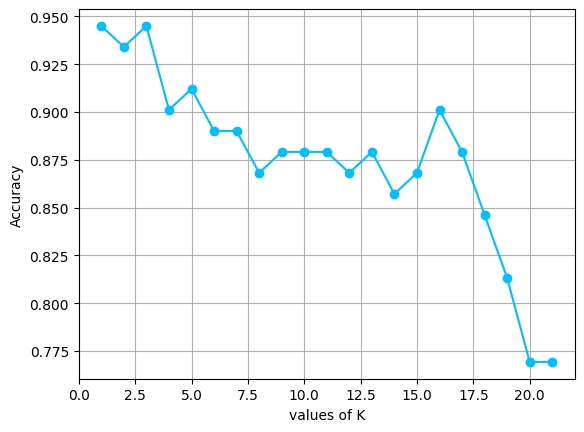

In [10]:
# accuracy_score_list
plt.plot(range(1,22), accuracy_score_list, color = 'deepskyblue', marker = 'o')
plt.xlabel('values of K')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

> Max Accuracy at **<span style = 'color:darkorange'>K = 3 & K = 1</span>**

Hence Takig help of cross validation

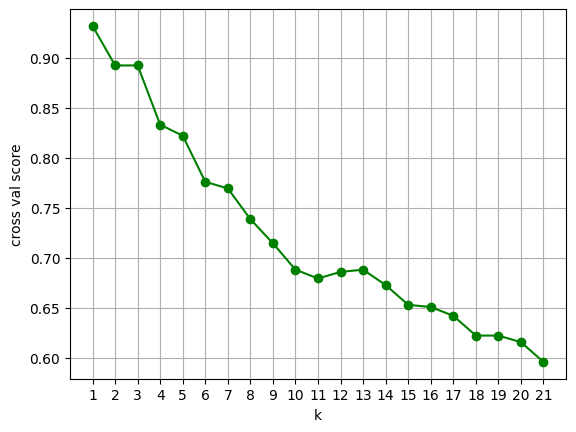

In [11]:
scores = []

for k in range(1, 22):
    knn = KNeighborsClassifier(n_neighbors=k)
    score = cross_val_score(knn, x, y, cv=5).mean()
    scores.append(score)

plt.xticks(range(1, 22))   # Show only integer values on x-axis
plt.plot(range(1,22), scores, label = 'cross val score', color = 'green', marker = 'o')
plt.xlabel('k')
plt.ylabel('cross val score')

plt.grid(True)
plt.show()

> Max cross_val_score at **<span style = 'color:darkorange'>K = 1</span>**

Hence training Model on K = 1.

In [12]:
# model train
KNN = KNeighborsClassifier(n_neighbors=1)
KNN.fit(x_train, y_train)
y_Pred = KNN.predict(x_test)

print('ACCURACY: ',accuracy_score(y_test, y_Pred))

ACCURACY:  0.945054945054945


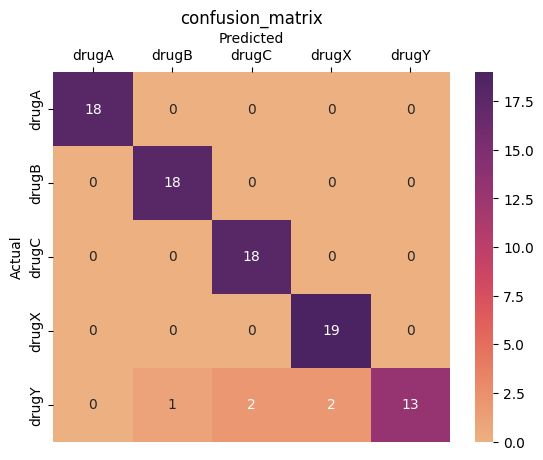

In [13]:
# confusion matrix
labels = ['drugA', 'drugB', 'drugC', 'drugX', 'drugY']
sns.heatmap(confusion_matrix(y_test, y_Pred), annot = True, xticklabels=labels, yticklabels=labels, cmap = 'flare')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.gca().xaxis.set_label_position("top")
plt.gca().xaxis.tick_top()
plt.title('confusion_matrix')
plt.show()

In [14]:
print(le_gender.classes_)
print(le_bp.classes_)
print(le_chol.classes_)
print(le_class.classes_)

['F' 'M']
['HIGH' 'LOW' 'NORMAL']
['HIGH' 'NORMAL']
['drugA' 'drugB' 'drugC' 'drugX' 'drugY']


In [16]:

age = int(input("Enter Age: "))
gender = input("Enter Gender (F/M): ").upper()
bp = input("Enter Blood Pressure (HIGH/LOW/NORMAL): ").upper()
chol = input("Enter Cholesterol (HIGH/NORMAL): ").upper()
na_to_k = float(input("Enter Na_to_K: "))

gender = le_gender.transform([gender])[0]
bp = le_bp.transform([bp])[0]
chol = le_chol.transform([chol])[0]

user = np.array([[age, gender, bp, chol, na_to_k]])
user = scaler.transform(user)

prediction = KNN.predict(user)
drug = le_class.inverse_transform(prediction)

print("Predicted Drug:", drug[0])

Predicted Drug: drugY


/Users/lucifer/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
